# GSE149614 primary-tumor macrophages: PGAM5 RNA detection

## tl;dr

Ten samples ending in T contain 34,414 primary-tumor cells. Marker-based selection identifies 6,151 cells in macrophage-enriched original myeloid clusters. Of these, 167 have PGAM5 counts >0 and 5,984 have no PGAM5 counts. RNA nondetection is not protein negativity.

With the requested pooled-cell Wilcoxon analysis, 512 upregulated and zero downregulated candidate genes pass BH FDR <0.05, absolute approximate log2FC >=1 and >=10% detection in either group, excluding PGAM5 itself. There are 76 shared upregulated candidates with the previous GSE151530 analysis. These are exploratory associations, not a validated PGAM5 protein-positive signature.


## Context & Methods

### Key assumptions

- Only samples ending in T with official site=Tumor are selected. N (normal), P (PVTT), and L (lymph node) samples are excluded from differential expression.
- Updated GEO metadata labels cells as Myeloid, not macrophages. Marker expression is summarized in the original global clusters using all sites to avoid unstable annotation of tiny tumor-only clusters.
- Macrophage enrichment rule: C1QA, C1QB and C1QC each detected in >=80% of cells, and CD68 in >=75% of cells. Selected clusters: 5, 6, 21, 23, 38, 39, 41, 44, 46. Additional markers CSF1R/CD163/SPP1 support interpretation. This is our marker-based annotation, not an author-provided refined macrophage label.
- Excluded: cluster 10 (DC-enriched/mixed antigen-presenting cells), 16/26 (FCN1/S100A8/A9 monocyte-enriched/transition cells), 52 (GZMB/JCHAIN pDC-enriched), 53 (TPSAB1/TPSB2 mast-cell-enriched). This conservative selection does not cover every possible monocyte-derived inflammatory TAM.
- Basic QC: >=500 detected genes and <20% mitochondrial counts; all 6,151 selected primary-tumor cells meet these cutoffs.
- Grouping: PGAM5 count >0 versus count=0. Total-count normalization to 10,000 followed by log1p. Pooled-cell Wilcoxon with tie correction and BH FDR; no patient pairing, depth matching or sample/depth covariates, as requested.
- PGAM5 is retained in full tables and excluded from candidate lists because it defines the groups. Other gene classes are not removed.
- Scanpy log2FC is an approximate fold change from back-transformed mean log expression. Ranking is by FDR; a top20 shortlist is not a validated signature.
- Technical depth, biological sample/state composition, ambient RNA and doublets remain possible contributors. Macrophage markers are widespread in both groups, but hepatic transcripts are also frequent. Dedicated ambient-RNA correction and doublet detection were not performed.

Preparation and model scripts have been executed and retained. This notebook executes source-backed result checks and figures from their outputs; it does not silently refit models.


In [1]:
from pathlib import Path
import json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
R=Path.cwd()
s=json.loads((R/'analysis_summary.json').read_text())
cross=json.loads((R/'cross_dataset_summary.json').read_text())
de=pd.read_csv(R/'GSE149614_primaryT_PGAM5_full_DE.csv',index_col=0)
up=pd.read_csv(R/'GSE149614_primaryT_PGAM5_upregulated.csv',index_col=0)
down=pd.read_csv(R/'GSE149614_primaryT_PGAM5_downregulated.csv',index_col=0)
markers=pd.read_csv(R/'original_myeloid_cluster_markers.csv')
annotation=pd.read_csv(R/'myeloid_cluster_annotation.csv')
samples=pd.read_csv(R/'primary_T_macrophages_by_sample.csv')
shared=pd.read_csv(R/'shared_upregulated_candidates_GSE149614_GSE151530.csv')
assert s['PGAM5_positive_cells']+s['PGAM5_undetected_cells']==s['QC_primary_macrophages']
assert len(up)==512 and len(down)==0 and len(shared)==76
assert up.FDR.lt(.05).all() and up.log2FC.ge(1).all() and not up.gene.eq('PGAM5').any()
assert samples['sample'].str.endswith('T').all() and samples['sample'].nunique()==10
assert up[['fraction_PGAM5_positive','fraction_PGAM5_undetected']].max(axis=1).ge(.1).all()
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':11,'axes.spines.top':False,'axes.spines.right':False,'figure.dpi':120,'savefig.bbox':'tight'})
BLUE='#355C8A';GOLD='#C68D29'
print('Count, scope and differential-threshold checks passed.')


Count, scope and differential-threshold checks passed.


## Data

Sources: [GEO series](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE149614), [updated metadata](https://ftp.ncbi.nlm.nih.gov/geo/series/GSE149nnn/GSE149614/suppl/GSE149614_HCC.metadata.updated.txt.gz), [raw processed counts](https://ftp.ncbi.nlm.nih.gov/geo/series/GSE149nnn/GSE149614/suppl/GSE149614_HCC.scRNAseq.S71915.count.txt.gz). Official GSM4505944 metadata also confirms HCC01T is primary HCC tumor.

The original matrix has 71,915 cells and 25,712 genes. Header IDs match metadata exactly and are unique; all parsed counts are nonnegative integers. Full gzip reading verifies CRC; input SHA256 hashes are recorded in input_sha256.json. Raw EGA sequence access is not needed for these publicly available processed counts.


In [2]:
display(pd.DataFrame({'quantity':['T samples','T cells','T myeloid cells','Selected/QC macrophages','PGAM5 detected','PGAM5 undetected','Upregulated candidates','Downregulated candidates','Shared upregulated with GSE151530'],'value':[10,34414,8209,6151,167,5984,512,0,76]}))
display(samples)


,quantity,value
0,T samples,10
1,T cells,34414
2,T myeloid cells,8209
3,Selected/QC macrophages,6151
4,PGAM5 detected,167
5,PGAM5 undetected,5984
6,Upregulated candidates,512
7,Downregulated candidates,0
8,Shared upregulated with GSE151530,76


,sample,macrophages,PGAM5_detected,PGAM5_detection_rate,median_counts
0,HCC01T,1145,41,0.035808,5817.0
1,HCC02T,444,24,0.054054,13610.0
2,HCC03T,932,19,0.020386,5232.0
3,HCC04T,568,35,0.061620,7466.0
4,HCC05T,963,18,0.018692,7515.0
5,HCC06T,488,7,0.014344,6615.5
6,HCC07T,138,3,0.021739,3327.0
7,HCC08T,702,8,0.011396,6814.0
8,HCC09T,293,1,0.003413,3793.0
9,HCC10T,478,11,0.023013,5222.0


## Results

### 1. Macrophage annotation evidence

This chart uses original all-site myeloid clusters only for annotation. Differential expression uses T samples exclusively. The marker-based rule is independent of PGAM5 detection.


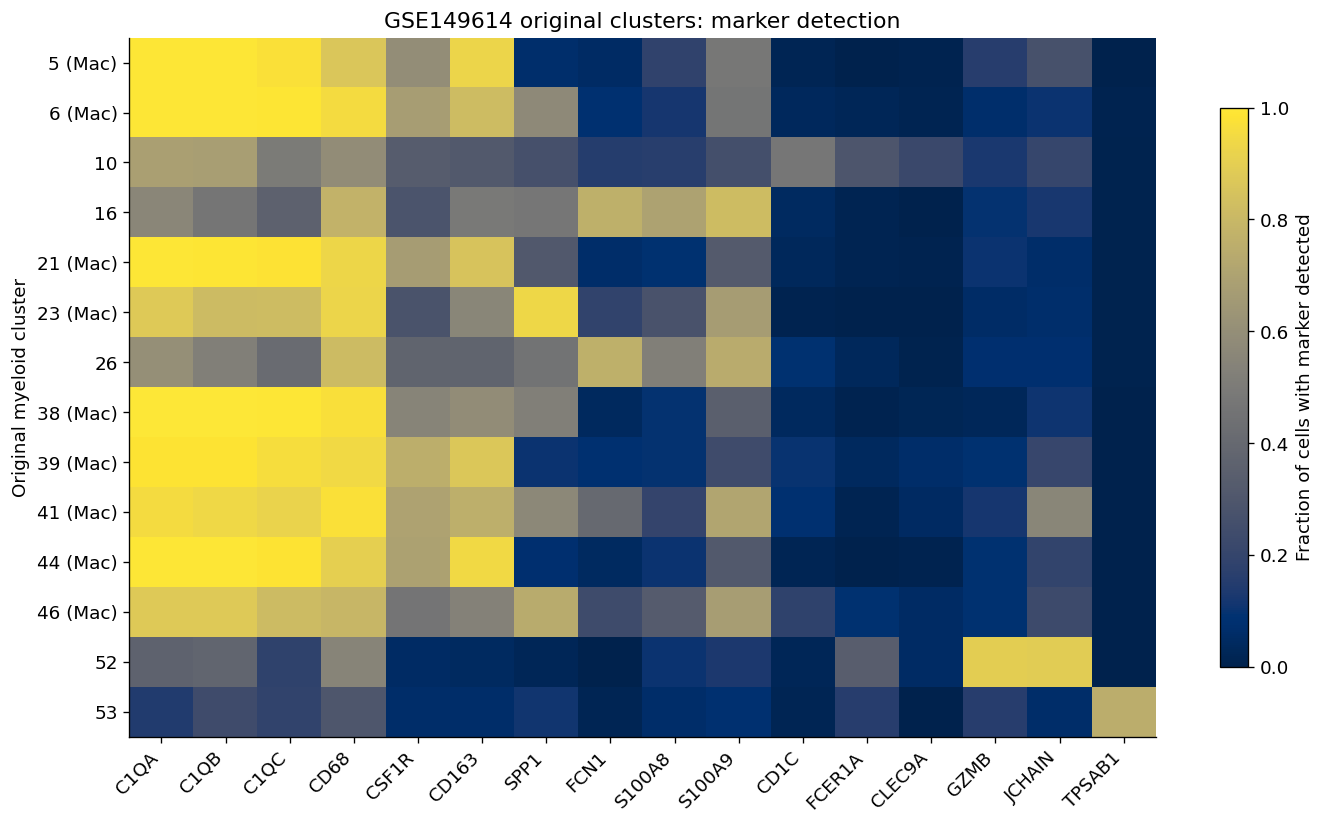

,cluster,included_macrophage_cluster,annotation
0,5,True,C1Q/CD68 macrophage-enriched
1,6,True,C1Q/CD68 macrophage-enriched
2,10,False,DC-enriched/mixed antigen-presenting myeloid
3,16,False,FCN1/S100A8/A9 monocyte-enriched
4,21,True,C1Q/CD68 macrophage-enriched
5,23,True,C1Q/CD68 macrophage-enriched
6,26,False,FCN1/S100A8/A9 monocyte-enriched
7,38,True,C1Q/CD68 macrophage-enriched
8,39,True,C1Q/CD68 macrophage-enriched
9,41,True,C1Q/CD68 macrophage-enriched


In [3]:
genes=['C1QA','C1QB','C1QC','CD68','CSF1R','CD163','SPP1','FCN1','S100A8','S100A9','CD1C','FCER1A','CLEC9A','GZMB','JCHAIN','TPSAB1']
t=markers.pivot(index='cluster',columns='gene',values='fraction').reindex(columns=genes)
selected=set(s['macrophage_clusters'])
fig,ax=plt.subplots(figsize=(12,7))
im=ax.imshow(t.to_numpy(),cmap='cividis',vmin=0,vmax=1,aspect='auto')
ax.set_xticks(np.arange(len(genes)),genes,rotation=45,ha='right')
ax.set_yticks(np.arange(len(t)),[f"{c} (Mac)" if c in selected else str(c) for c in t.index])
ax.set_ylabel('Original myeloid cluster');ax.set_title('GSE149614 original clusters: marker detection')
fig.colorbar(im,ax=ax,label='Fraction of cells with marker detected',shrink=.8)
fig.tight_layout();fig.savefig(R/'myeloid_annotation_markers.png');fig.savefig(R/'myeloid_annotation_markers.pdf');plt.show()
display(annotation)


### 2. PGAM5 detection in primary-tumor macrophages

All ten T samples contribute macrophages. Percentages are descriptive cell fractions, not estimates of protein-positive macrophages.


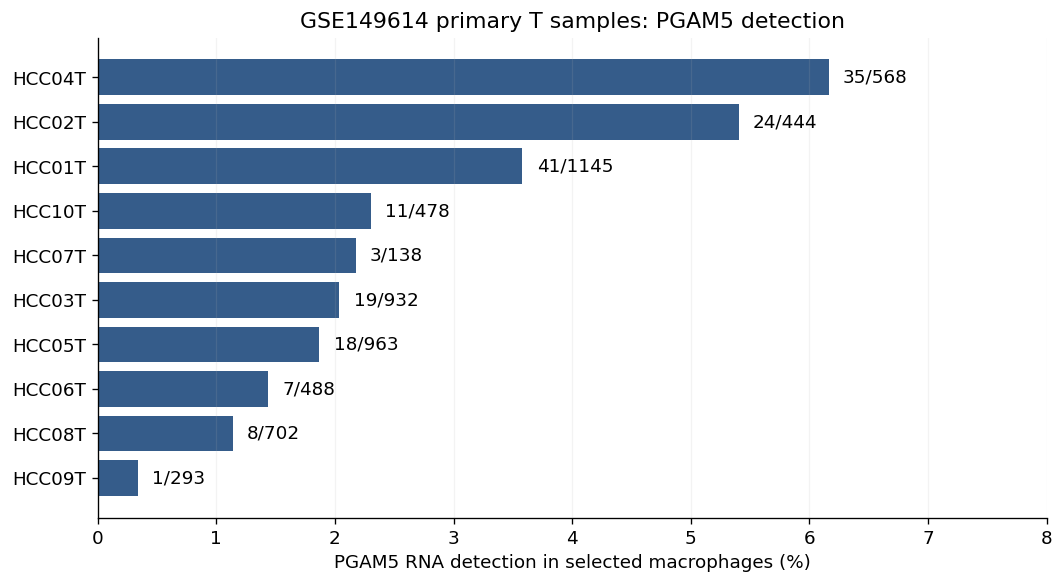

In [4]:
t=samples.sort_values('PGAM5_detection_rate',ascending=True).reset_index(drop=True)
fig,ax=plt.subplots(figsize=(9,5))
ax.barh(t['sample'],t.PGAM5_detection_rate*100,color=BLUE)
ax.set_xlabel('PGAM5 RNA detection in selected macrophages (%)')
ax.set_title('GSE149614 primary T samples: PGAM5 detection')
ax.set_xlim(0,8)
for i,row in t.iterrows():ax.text(row.PGAM5_detection_rate*100+.12,i,f"{row.PGAM5_detected}/{row.macrophages}",va='center')
ax.grid(axis='x',alpha=.15)
fig.tight_layout();fig.savefig(R/'PGAM5_detection_primaryT.png');fig.savefig(R/'PGAM5_detection_primaryT.pdf');plt.show()


### 3. Pooled-cell differential expression

The plot shows genes detected in >=10% of cells in either group. Orange points pass the final FDR/effect-size thresholds; blue points do not. PGAM5, the defining gene, is excluded from the plot. This is the requested unpaired cell-level analysis, and no sample-level validation is implied.


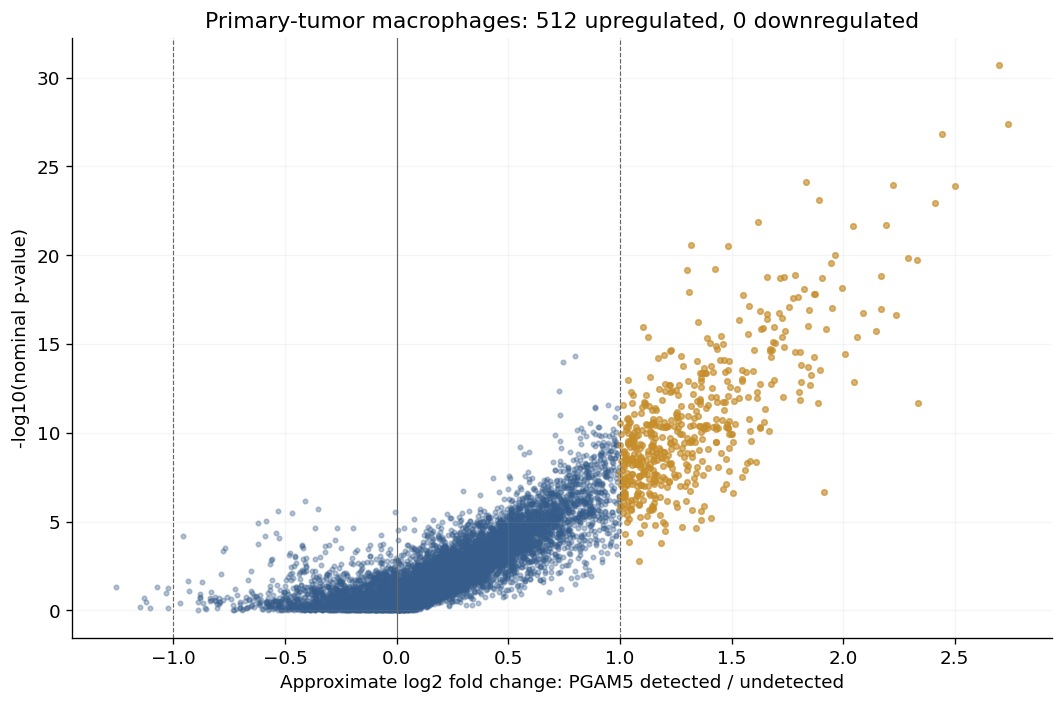

,gene,log2FC,FDR,fraction_PGAM5_positive,fraction_PGAM5_undetected
names,,,,,
TUSC3,TUSC3,2.696823,1.235113e-27,0.131737,0.013536
TBX3,TBX3,2.737650,9.890955e-25,0.107784,0.010194
PLEKHF1,PLEKHF1,2.442340,2.649699e-24,0.191617,0.031584
CHMP4C,CHMP4C,1.833750,8.221621e-22,0.107784,0.011531
LINC01419,LINC01419,2.222751,1.152635e-21,0.131737,0.017213
ABCC2,ABCC2,2.502664,1.239589e-21,0.113772,0.013035
AGXT2,AGXT2,1.891074,7.258612e-21,0.125749,0.016210
FAM133A,FAM133A,2.410768,9.927669e-21,0.101796,0.010862
RP1-28O10.1,RP1-28O10.1,1.619465,1.077871e-19,0.107784,0.012701


In [5]:
d=de[(~de.defining_gene)&de[['fraction_PGAM5_positive','fraction_PGAM5_undetected']].max(axis=1).ge(.1)].dropna(subset=['log2FC','p_value'])
passed=d.FDR.lt(.05)&d.log2FC.abs().ge(1)&d[['fraction_PGAM5_positive','fraction_PGAM5_undetected']].max(axis=1).ge(.1)
fig,ax=plt.subplots(figsize=(9,6))
ax.scatter(d.loc[~passed,'log2FC'],-np.log10(d.loc[~passed,'p_value'].clip(lower=1e-300)),s=7,color=BLUE,alpha=.35)
ax.scatter(d.loc[passed,'log2FC'],-np.log10(d.loc[passed,'p_value'].clip(lower=1e-300)),s=11,color=GOLD,alpha=.65)
ax.axvline(0,color='#666666',lw=.7);ax.axvline(1,color='#666666',lw=.7,ls='--');ax.axvline(-1,color='#666666',lw=.7,ls='--')
ax.set_xlabel('Approximate log2 fold change: PGAM5 detected / undetected')
ax.set_ylabel('-log10(nominal p-value)');ax.set_title('Primary-tumor macrophages: 512 upregulated, 0 downregulated')
ax.grid(alpha=.12)
fig.tight_layout();fig.savefig(R/'PGAM5_primaryT_differential_expression.png');fig.savefig(R/'PGAM5_primaryT_differential_expression.pdf');plt.show()
display(up[['gene','log2FC','FDR','fraction_PGAM5_positive','fraction_PGAM5_undetected']].head(20))


### 4. Comparison with GSE151530

Both cohorts use the same expression/DE thresholds and pooled-cell tests. GSE151530 uses its original TAM annotation; GSE149614 uses marker-defined macrophage-enriched clusters. This population difference must be considered when interpreting the overlap. Shared associations are candidates for further investigation, not proof of a specific PGAM5-driven mechanism.


In [6]:
display(shared[['gene','log2FC_GSE149614','FDR_GSE149614','log2FC_GSE151530','FDR_GSE151530']].head(20))
qa=pd.read_csv(R/'macrophage_and_hepatocyte_marker_QA.csv')
display(qa.pivot(index='gene',columns='group',values='fraction').round(3))


,gene,log2FC_GSE149614,FDR_GSE149614,log2FC_GSE151530,FDR_GSE151530
0,CENPK,1.825214,2.533921e-16,1.888786,6.932816e-14
1,MYBL2,2.148458,2.940808e-14,2.176081,8.408517e-14
2,ATAD2,1.738790,3.052683e-14,1.673484,7.015177e-13
3,DONSON,1.132699,7.163691e-12,1.628036,1.319673e-12
4,FEN1,1.223675,3.926493e-11,1.525940,5.126880e-11
5,ASF1B,1.696903,1.239467e-13,1.805007,9.363782e-11
6,TUBG1,1.484496,6.571820e-11,1.192670,1.150248e-10
7,TUSC3,2.696823,1.235113e-27,2.003528,1.529589e-10
8,FAM114A1,1.478712,1.125647e-11,1.093596,1.602814e-10
9,TOP2A,1.465012,3.293073e-10,1.573388,7.217715e-12


group,PGAM5_detected,PGAM5_undetected
gene,,
ALB,0.928,0.868
APOA1,0.802,0.784
APOA2,0.958,0.928
APOC3,0.826,0.745
C1QA,0.988,0.970
C1QB,0.976,0.957
C1QC,0.976,0.955
CD3D,0.156,0.095
CD3E,0.078,0.050


## Takeaways

The requested analysis produces 512 upregulated candidate genes. The 76 shared upregulated genes are a useful next-stage candidate pool; a top-ranked list alone does not establish a gene signature. Hepatic transcripts are frequent despite strong macrophage markers in both groups, so ambient RNA, phagocytosed transcripts and mixed cells remain possible explanations for some associations. They were not resolved in this workflow.

### Reproduction

Download the official metadata and count files, install the scientific dependencies listed in environment_versions.txt, and run prepare_myeloid.py then analyze_primary_macrophages.py. Scripts currently use /workspace/scratch/GSE149614; adjust paths when rerunning elsewhere. All-site counts are used only to annotate original myeloid clusters; DE uses T samples exclusively.

Retained tables support reproducing the displayed figures. The full model can be rerun from official inputs using the scripts. No pathway enrichment or independent signature scoring is claimed. Notebook code cells execute top-to-bottom; PNG/PDF figures are exported for inspection and use.
